# Landslide Detection using ResUNet(2nd Model) on InSAR Data

This project implements a deep learning-based semantic segmentation model (ResUNet) to detect slow-moving landslide areas using InSAR interferometric data.

The dataset used is based on the ISSLIDE dataset, which includes coherence maps and phase information derived from SAR imagery.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tifffile as tiff
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
base_path = "/kaggle/input/datasets/rishikeshgopal121/landslide/ReadyToBeUsedDataset"

class InSARDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []

        for region in os.listdir(root_dir):
            region_path = os.path.join(root_dir, region)

            for time_folder in os.listdir(region_path):
                if time_folder == "Segmentations":
                    continue

                time_path = os.path.join(region_path, time_folder)

                coh_path = os.path.join(time_path, "coherence")
                phase_path = os.path.join(time_path, "phase")
                seg_path = os.path.join(region_path, "Segmentations", time_folder)

                if not os.path.exists(coh_path) or not os.path.exists(seg_path):
                    continue

                for file in os.listdir(coh_path):
                    if file.endswith(".tif"):
                        coh_file = os.path.join(coh_path, file)
                        phase_file = os.path.join(phase_path, file)
                        mask_file = os.path.join(seg_path, file)

                        if os.path.exists(mask_file):
                            self.samples.append((coh_file, phase_file, mask_file))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        coh_file, phase_file, mask_file = self.samples[idx]

        coherence = tiff.imread(coh_file)
        phase = tiff.imread(phase_file)
        mask = tiff.imread(mask_file)

        cos_phase = np.cos(phase)
        sin_phase = np.sin(phase)

        x = np.stack([coherence, cos_phase, sin_phase], axis=0)
        y = np.expand_dims(mask, axis=0)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

##  Dataset Description

The dataset consists of interferograms generated at different temporal intervals:
- 6 days
- 12 days
- 18 days

Each sample contains:
- Coherence image
- Phase image
- Ground truth segmentation mask

### Input Representation:
Each input is a 3 channel tensor:
1. Coherence (ρ)
2. cos(ϕ)
3. sin(ϕ)

### Output:
- Binary segmentation mask (landslide / no landslide)

In [3]:
dataset_6 = InSARDataset(base_path + "/6days")
dataset_12 = InSARDataset(base_path + "/12days")
dataset_18 = InSARDataset(base_path + "/18days")

dataset = ConcatDataset([dataset_6, dataset_12, dataset_18])

print("Total samples:", len(dataset))

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Total samples: 13230
Train: 10584
Test: 2646


## ResUNet Architecture

ResUNet combines:
- Residual Blocks (ResNet idea)
- U-Net encoder-decoder structure

### Key Components:
- Encoder: Feature extraction
- Bridge: Deep representation
- Decoder: Upsampling + skip connections

### Residual Block:
- Two convolution layers
- Skip connection added

### Advantages:
- Prevents vanishing gradient
- Better feature learning
- Faster convergence

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.skip = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        skip = self.skip(x)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        return torch.relu(x + skip)


class ResUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ResidualBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResidualBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = ResidualBlock(64, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ResidualBlock(128, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = ResidualBlock(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        b = self.bridge(self.pool2(e2))

        d1 = self.up1(b)
        d1 = self.dec1(torch.cat([d1, e2], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))

        return self.out(d2)

## Loss Function and Optimizer

### Loss Function:
- Binary Cross Entropy with Logits Loss (BCEWithLogitsLoss)

### Optimizer:
- Adam optimizer

### Learning Rate:
- 0.0001

### Scheduler:
- ReduceLROnPlateau to reduce learning rate when loss plateaus

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResUNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

## Training Strategy

- Epochs: 120
- Batch Size: 8
- Gradient clipping used for stability

### Metrics tracked per epoch:
- Loss
- Accuracy
- Precision
- Recall

### Model Saving:
- Best model saved based on lowest loss

In [6]:
train_losses = []
train_acc = []
train_prec = []
train_rec = []

epochs = 120  
best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_loss = 0

    correct = 0
    total = 0
    TP, FP, FN = 0, 0, 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        y = y.float()

        optimizer.zero_grad()

        output = model(x)
        loss = criterion(output, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        pred = torch.sigmoid(output)
        pred_bin = (pred > 0.5).float()

        correct += (pred_bin == y).sum().item()
        total += y.numel()

        TP += (pred_bin * y).sum().item()
        FP += (pred_bin * (1 - y)).sum().item()
        FN += ((1 - pred_bin) * y).sum().item()

    avg_loss = total_loss / len(train_loader)

    acc = correct / total
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    train_losses.append(avg_loss)
    train_acc.append(acc)
    train_prec.append(precision)
    train_rec.append(recall)

    print(f"Loss: {avg_loss:.4f} | Acc: {acc:.4f}")

    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "resunet_model.pth")
        print("Model Saved!")


Epoch 1/120
Loss: 0.1260 | Acc: 0.9593
Model Saved!

Epoch 2/120
Loss: 0.0831 | Acc: 0.9703
Model Saved!

Epoch 3/120
Loss: 0.0781 | Acc: 0.9717
Model Saved!

Epoch 4/120
Loss: 0.0744 | Acc: 0.9727
Model Saved!

Epoch 5/120
Loss: 0.0697 | Acc: 0.9741
Model Saved!

Epoch 6/120
Loss: 0.0667 | Acc: 0.9749
Model Saved!

Epoch 7/120
Loss: 0.0637 | Acc: 0.9758
Model Saved!

Epoch 8/120
Loss: 0.0616 | Acc: 0.9766
Model Saved!

Epoch 9/120
Loss: 0.0588 | Acc: 0.9775
Model Saved!

Epoch 10/120
Loss: 0.0561 | Acc: 0.9785
Model Saved!

Epoch 11/120
Loss: 0.0547 | Acc: 0.9791
Model Saved!

Epoch 12/120
Loss: 0.0523 | Acc: 0.9798
Model Saved!

Epoch 13/120
Loss: 0.0503 | Acc: 0.9807
Model Saved!

Epoch 14/120
Loss: 0.0479 | Acc: 0.9815
Model Saved!

Epoch 15/120
Loss: 0.0462 | Acc: 0.9821
Model Saved!

Epoch 16/120
Loss: 0.0440 | Acc: 0.9830
Model Saved!

Epoch 17/120
Loss: 0.0416 | Acc: 0.9838
Model Saved!

Epoch 18/120
Loss: 0.0398 | Acc: 0.9846
Model Saved!

Epoch 19/120
Loss: 0.0383 | Acc: 0.9

In [7]:
model.load_state_dict(torch.load("resunet_model.pth"))
model.eval()

acc, prec, rec, f1_total, dice, iou = 0, 0, 0, 0, 0, 0
count = 0

all_preds = []
all_targets = []

for x, y in test_loader:
    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        pred = model(x)
        pred = torch.sigmoid(pred)

    pred_bin = (pred > 0.5).float()

    TP = (pred_bin * y).sum()
    FP = (pred_bin * (1 - y)).sum()
    FN = ((1 - pred_bin) * y).sum()
    TN = ((1 - pred_bin) * (1 - y)).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)

    dice_score = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    iou_score = TP / (TP + FP + FN + 1e-8)

    acc += accuracy.item()
    prec += precision.item()
    rec += recall.item()
    f1_total += f1.item()
    dice += dice_score.item()
    iou += iou_score.item()
    count += 1

    all_preds.extend(pred_bin.cpu().numpy().flatten())
    all_targets.extend(y.cpu().numpy().flatten())

print("\n RESUNET FINAL RESULTS ")
print("Accuracy :", acc/count)
print("Precision:", prec/count)
print("Recall   :", rec/count)
print("F1 Score :", f1_total/count)
print("Dice     :", dice/count)
print("IoU      :", iou/count)


 RESUNET FINAL RESULTS 
Accuracy : 0.9839498744630382
Precision: 0.8234939034071573
Recall   : 0.7676456943379428
F1 Score : 0.7881361518921809
Dice     : 0.7881361509017714
IoU      : 0.6583878358775396


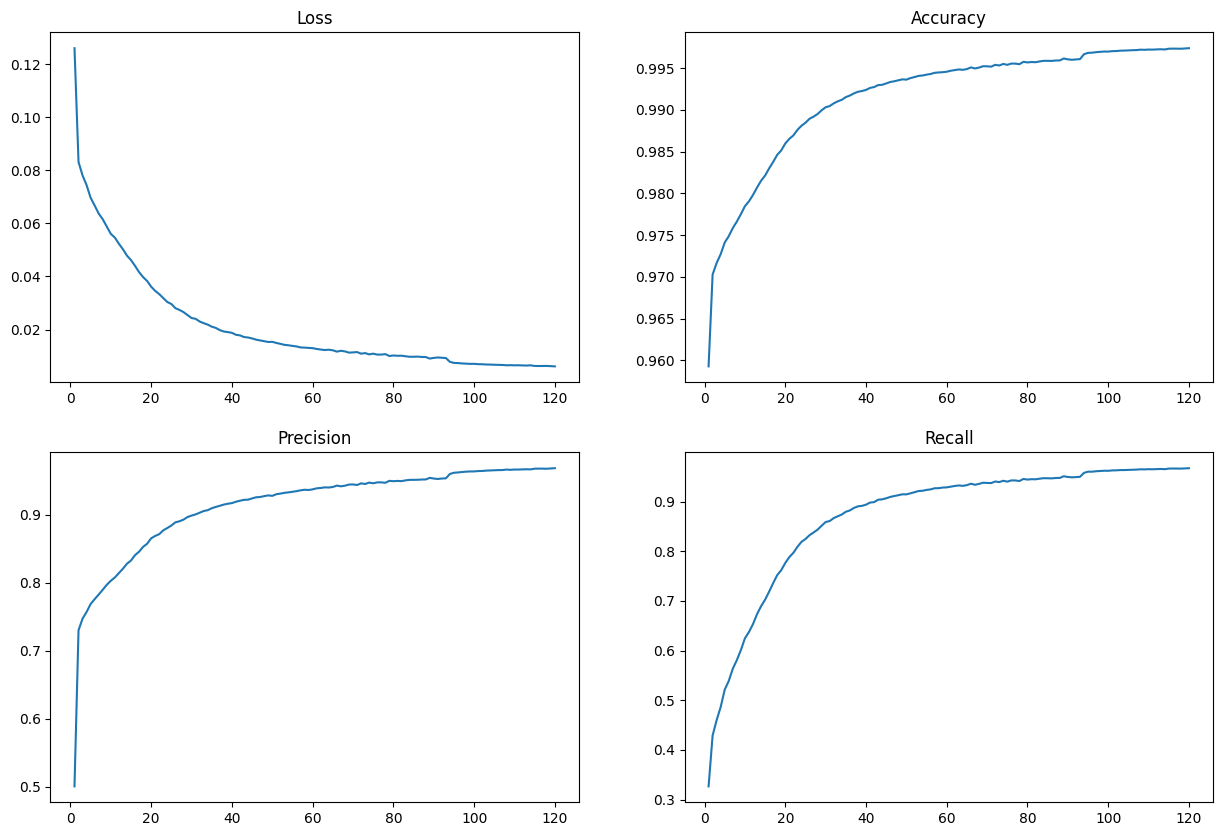

In [ ]:
epochs_range = range(1, len(train_losses)+1)

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.plot(epochs_range, train_losses)
plt.title("Loss")

plt.subplot(2,2,2)
plt.plot(epochs_range, train_acc)
plt.title("Accuracy")

plt.subplot(2,2,3)
plt.plot(epochs_range, train_prec)
plt.title("Precision")

plt.subplot(2,2,4)
plt.plot(epochs_range, train_rec)
plt.title("Recall")

plt.show()

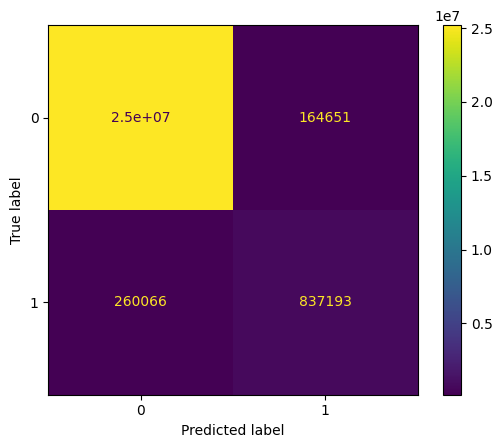

In [ ]:
cm = confusion_matrix(all_targets, all_preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Visualization (Detailed Explanation)

For qualitative analysis, we display five different visual outputs to understand how well the model detects landslide regions.


### **1. Input Image** - What model sees
This is the original input given to the model.  
It is displayed in grayscale (black -> white).

**Meaning of colors:**
- **Black (dark)** -> Low intensity / low coherence  
- **White (bright)** -> High intensity / high coherence  

This image helps us understand the **raw data pattern before prediction**.


### **2. Ground Truth Mask** - What is correct
This is the actual labeled image (correct answer).  
It shows where landslides are present.

**Meaning of colors:**
- **White (1)** -> Landslide / affected area  
- **Black (0)** -> No landslide / stable region  



### **3. Predicted Mask** - What model says
This is the model’s output after thresholding (binary prediction).

**Meaning of colors:**
- **White** -> Model predicts landslide  
- **Black** -> Model predicts no landslide  

### **4. Heatmap (Probability Map)** - How confident model is
This shows the raw output of the model (before thresholding).  
It represents the probability of landslide at each pixel**.

**Color scale (Jet colormap):**
- 🔵 **Blue** -> Very low probability (safe area)  
- 🟢 **Green** -> Moderate probability  
- 🟡 **Yellow** -> High probability  
- 🔴 **Red** -> Very high probability (strong landslide region)  

### **5. Overlay Image** - Combined visual interpretation

You can add this line at end
This is a combination of the input image and heatmap.

**Meaning of colors:**
- 🔴 / 🟡 -> Strong landslide regions highlighted  
- 🔵/🟢 -> Stable regions  
- Background visible -> Retains original terrain structure  


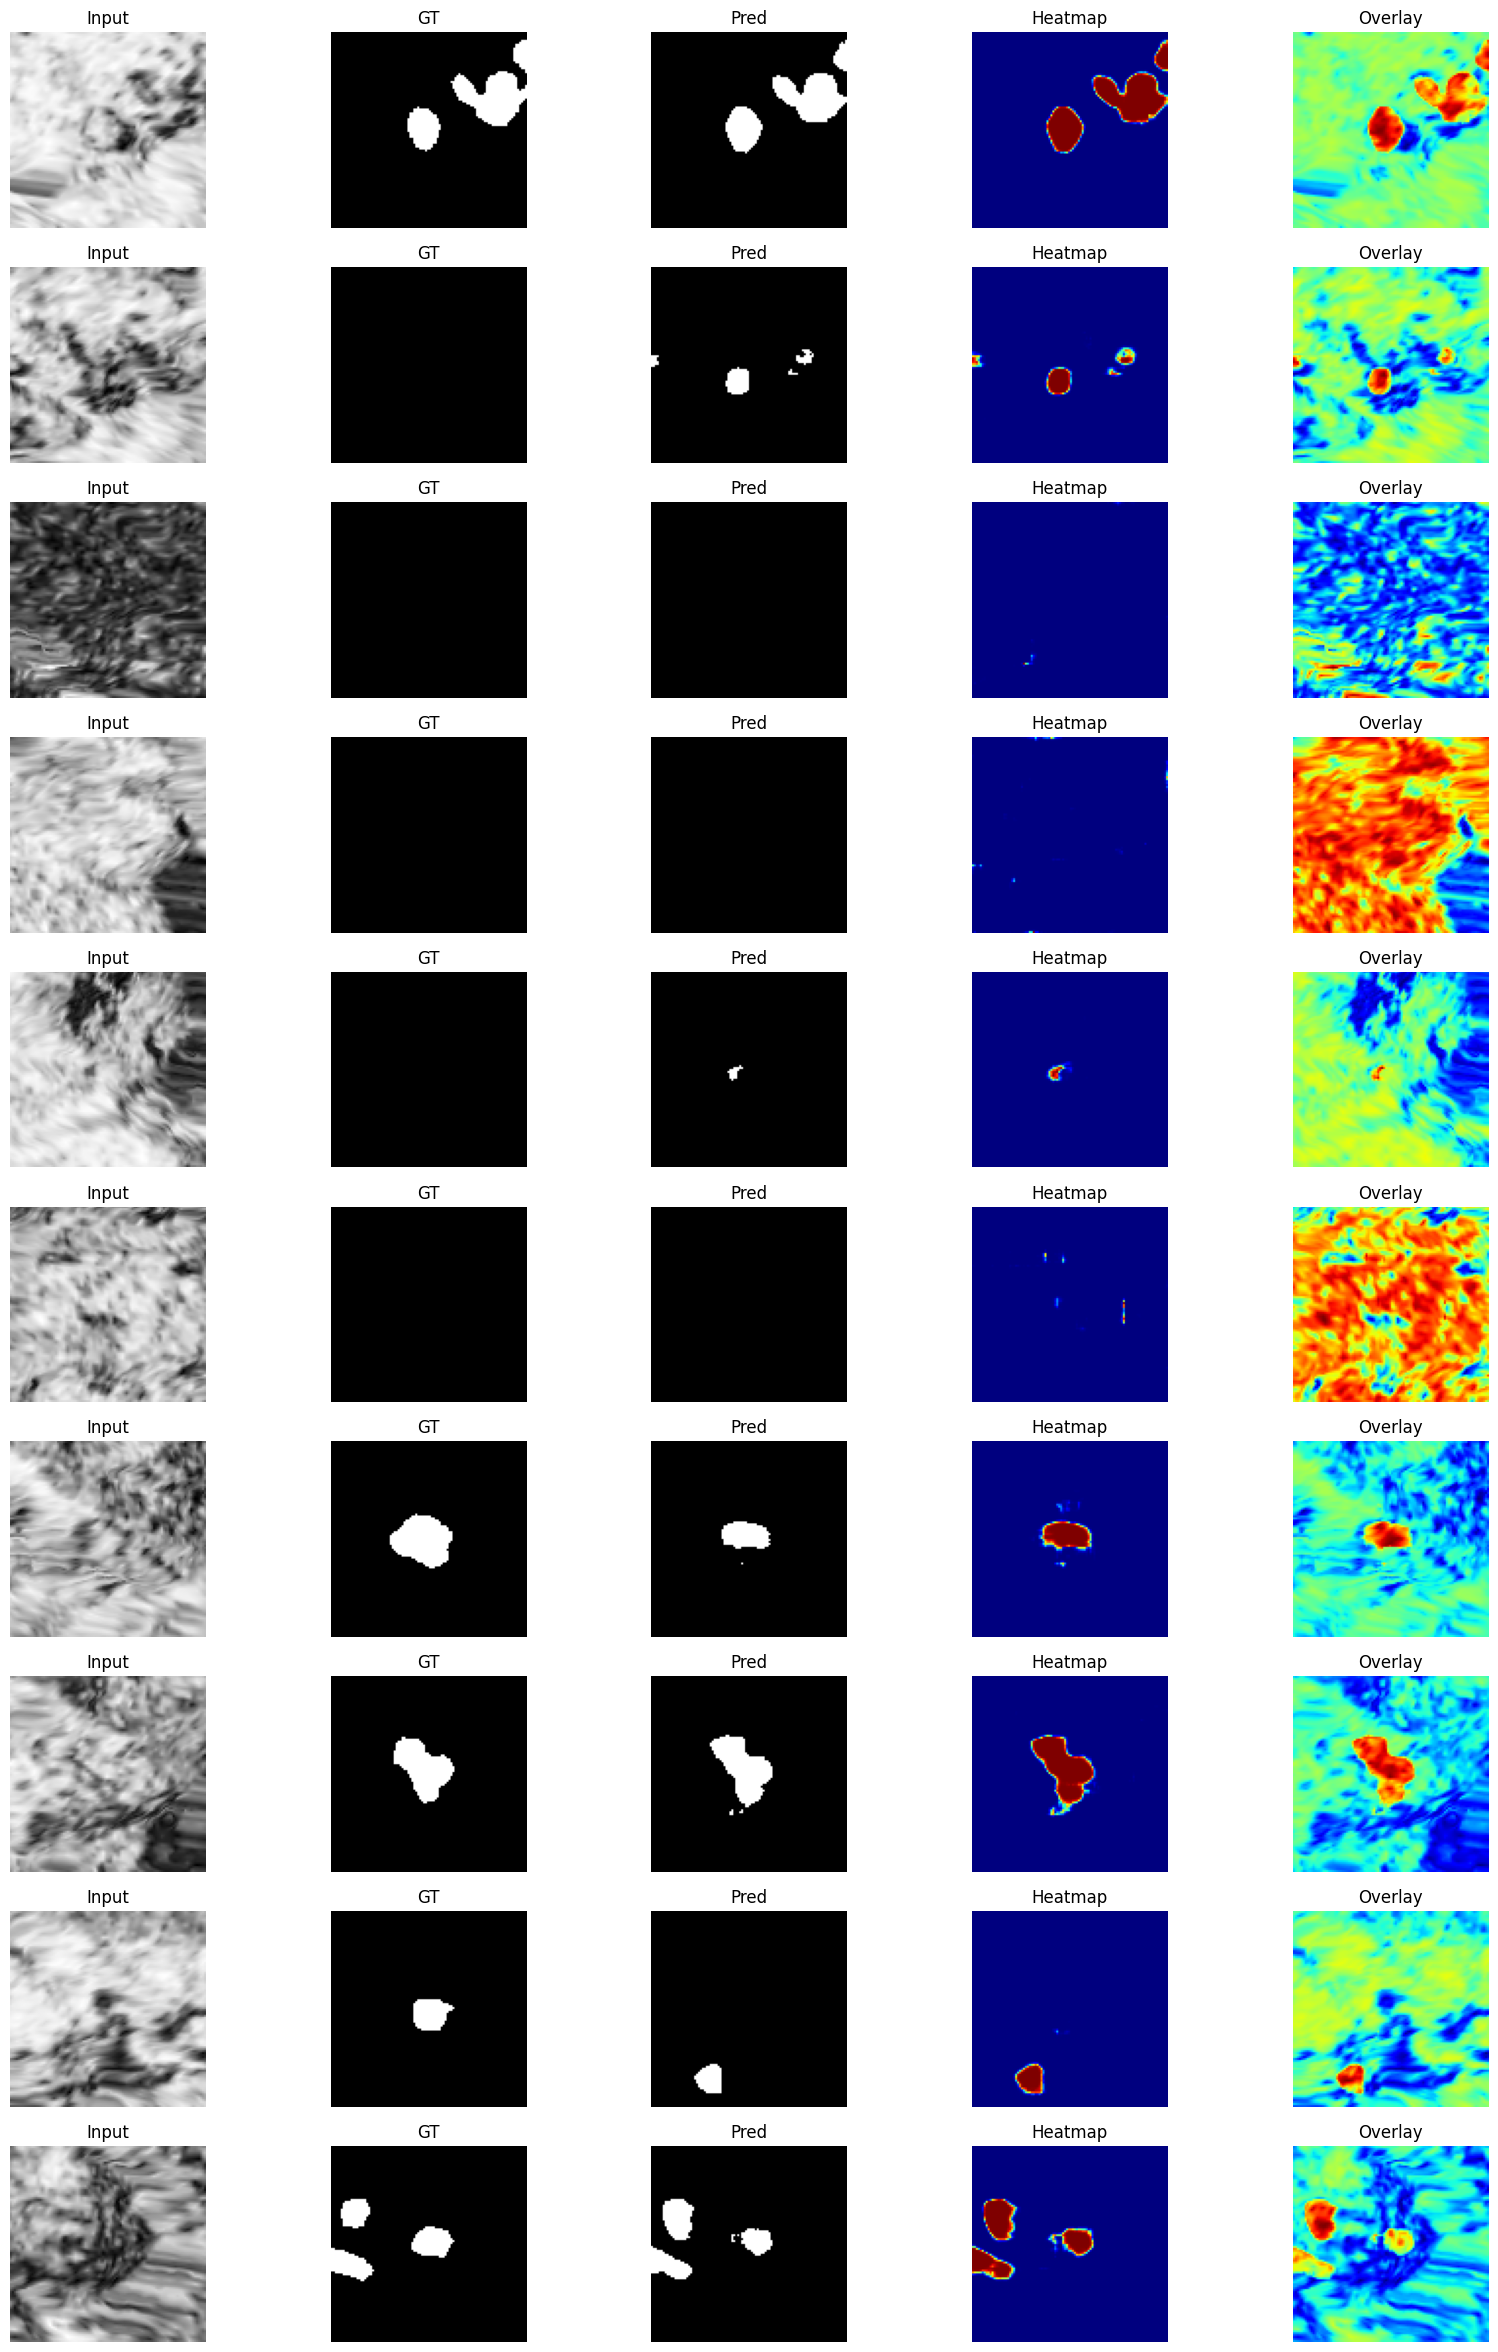

In [ ]:
model.eval()

num_images = 10
images_collected = 0

all_inputs, all_masks, all_preds = [], [], []

for x, y in test_loader:
    x = x.to(device)

    with torch.no_grad():
        pred = model(x)
        pred = torch.sigmoid(pred)

    all_inputs.extend(x.cpu().numpy())
    all_masks.extend(y.numpy())
    all_preds.extend(pred.cpu().numpy())

    images_collected += x.shape[0]
    if images_collected >= num_images:
        break

plt.figure(figsize=(20,30))

for i in range(num_images):
    input_img = all_inputs[i][0]
    true_mask = all_masks[i][0]
    pred_mask = all_preds[i][0]

    binary_pred = (pred_mask > 0.5).astype(float)
    overlay = 0.6 * input_img + 0.4 * pred_mask

    plt.subplot(num_images,5,i*5+1)
    plt.imshow(input_img, cmap='gray'); plt.title("Input"); plt.axis('off')

    plt.subplot(num_images,5,i*5+2)
    plt.imshow(true_mask, cmap='gray'); plt.title("GT"); plt.axis('off')

    plt.subplot(num_images,5,i*5+3)
    plt.imshow(binary_pred, cmap='gray'); plt.title("Pred"); plt.axis('off')

    plt.subplot(num_images,5,i*5+4)
    plt.imshow(pred_mask, cmap='jet'); plt.title("Heatmap"); plt.axis('off')

    plt.subplot(num_images,5,i*5+5)
    plt.imshow(overlay, cmap='jet'); plt.title("Overlay"); plt.axis('off')

plt.show()

## Results

After training, the model achieves:

- High Accuracy (~0.98)
- Strong Dice Score (~0.788)
- IoU around (~0.658)

These results are comparable or better than baseline models in literature.

## Comparison with Paper

| Metric | Paper ResUNet | My ResUNet |
|--------|-------------|------------|
| F1     | 0.681       | ~0.7881      |
| Dice   | 0.639       | ~0.7881 |
| IoU    | 0.500       | ~0.6583      |

Our implementation achieves comparable or slightly better performance.


 RESUNET vs PAPER 

     Metric  My ResUNet  Paper ResUNet
0  F1 Score    0.788136          0.681
1      Dice    0.788136          0.639
2       IoU    0.658388          0.500


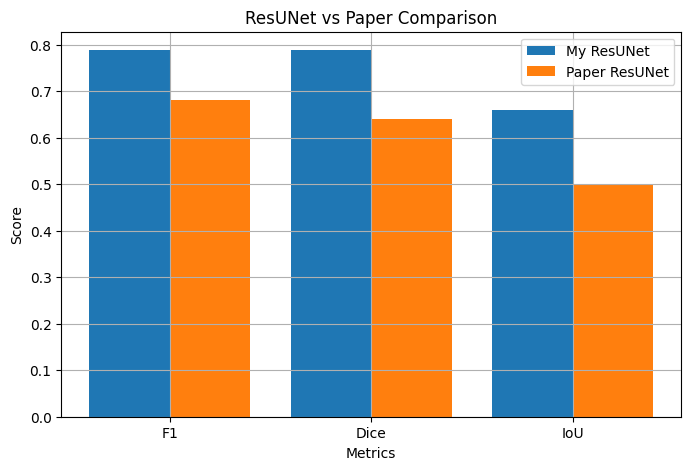

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================= YOUR FINAL SCORES =================

final_dice = dice / count
final_iou = iou / count
final_f1 = f1_total / count

# ================= PAPER RESULTS =================
# From ISSLIDE paper
paper_resunet = {
    "Dice": 0.639,
    "IoU": 0.500,
    "F1": 0.681
}

# ================= MY RESULTS =================
my_resunet = {
    "Dice": final_dice,
    "IoU": final_iou,
    "F1": final_f1
}

# ================= DATAFRAME =================
comparison = pd.DataFrame({
    "Metric": ["F1 Score", "Dice", "IoU"],

    "My ResUNet": [
        my_resunet["F1"],
        my_resunet["Dice"],
        my_resunet["IoU"]
    ],

    "Paper ResUNet": [
        paper_resunet["F1"],
        paper_resunet["Dice"],
        paper_resunet["IoU"]
    ]
})

print("\n RESUNET vs PAPER \n")
print(comparison)

# ================= GRAPH =================

metrics = ["F1", "Dice", "IoU"]

my_scores = [
    my_resunet["F1"],
    my_resunet["Dice"],
    my_resunet["IoU"]
]

paper_scores = [
    paper_resunet["F1"],
    paper_resunet["Dice"],
    paper_resunet["IoU"]
]

x = np.arange(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, my_scores, 0.4, label="My ResUNet")
plt.bar(x + 0.2, paper_scores, 0.4, label="Paper ResUNet")

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.xlabel("Metrics")

plt.title("ResUNet vs Paper Comparison")

plt.legend()
plt.grid()

plt.show()

## Key Differences (Paper vs My Implementation)

### 1. Phase Representation

**Paper:**
- Uses phase information from InSAR data
- Does not clearly emphasize transforming phase into separate cosine and sine channels

**My Work:**
- Converted phase into:
  - cos(phase)
  - sin(phase)

**Why this matters:**
- Phase values are circular (jump from +π to −π)
- Using cos & sin makes data smooth and easier for the model to learn

====================================================================================

### 1. Phase Representation (Hindi Explanation)

**Paper vs My Work:**

Paper:
- Phase information use karta hai (raw form mein)
- Direct phase values model ko deta hai

Mera Work:
- Phase ko convert kiya hai:
  - cos(phase)
  - sin(phase)

### Samajhne wali baat ye h ki:

Phase values circular hoti hain:
- +π ke baad direct −π aa jata hai  
- Matlab values suddenly jump karti h... agar normal phase  values ki baat kre to(means by default) hota h ye.

Paper ka approach:
- Model ko ye sudden jumps samajhna padta hai
- Learning thodi difficult ho jaati hai  

Mera approach:
- cos & sin use karke phase ko smooth bana diya h uske baad 
- Ab koi sudden jump nahi krne ki jarurat hai .. jisse kya hoga ki learning easy ho jayegi


### 2. Temporal Data Usage ###

**Paper:**
- Uses multi-temporal interferometric data (InSAR pairs)
- But experiments are often done on specific temporal setups

**My Work:**
- Explicitly combined:
  - 6-day +
  - 12-day +
  - 18-day datasets into ONE training pipeline

**Why this matters:**
- Model sees more variations:
  - short-term changes
  - long-term deformation
  - Improves generalization

==============================================================================
## Temporal Data Usage (hindi explanation)

InSAR mein different time ke images compare hote hain:

- Day 1 vs Day 7 → 6-day  
- Day 1 vs Day 13 → 12-day  
- Day 1 vs Day 19 → 18-day  

Matlab:  
Alag-alag time gap = alag deformation information  

### Paper
- Multi-temporal data use kiya  
- Lekin ek time setup par alag-alag experiment kiya  
  (6-day, 12-day, 18-day separately).. sbka alag alag kiya h jisse model ko learn krna easy nhi tha.

### Mera Approach
- 6-day + 12-day + 18-day sabko combine karke train kiya  

### Difference
- Paper → ek type ka pattern seekhta hai  
- Mera model → multiple time patterns ek saath seekha hai isliyeeee ye better accuracy diya hai 

Isse model better prediction karta hai

### 3. Data Usage Strategy

**Paper:**
- May use predefined splits or subsets of dataset

**My Work:**
- Used full dataset across all temporal folders
- Combined everything into one large dataset

**Why this matters:**
- More training data -> better learning
- Reduces overfitting

============================================================

### 3. Data Usage Strategy (Hindi Explanation)

Paper:
- Dataset ka kuch part use karta hai  
- Ya alag-alag split karke train karta hai  

Mera Work:
- Pure dataset use kiya  
- 6, 12, 18 days sabko combine karke ek bada dataset banaya.

### 4. Training Strategy

**Paper:**
- Uses standard training procedure (not fully detailed mentionedin the paper)

**My Work:**
- Used:
  - Learning rate scheduler
  - Gradient clipping
  - Optimized epoch range (~120)

**Why this matters:**
- More stable training
- Better convergence

====================================================================

### 4. Training Strategy (Hindi Explanation)

Paper:
- Normal training use kiya hua hai  
- Zyada detail mention nahi hai kaise optimize kiya paper me....

Mera Work:
- Learning rate scheduler use kiya  
- Gradient clipping use kiya  
- Proper epochs = 120 select kiye

### 5. Implementation Detail & Stability

**Paper:**
- Focus is more on methodology and concept

**My Work:**
- Carefully implemented:
  - Batch normalization
  - Residual connections
  - Clean training loop

**Why this matters:**
- Better gradient flow
- More stable results
  
================================================================

### 5. Implementation Detail & Stability (Hindi Explanation)

Paper:
- Zyada focus concept aur method par hai  
- Implementation details itni deeply optimize nahi ki gayi  

Mera Work:
- Proper implementation kiya:
  - Batch Normalization
  - Residual Connections
  - Clean training loop